# [직장인과 문과생을 위한 수학교실 4기] 21. 미적분학 훈련 설계-09강 4기 21강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, y, h = sp.symbols("x y h", real=True)

Matplotlib is building the font cache; this may take a moment.


## 0. 미분 = 선형화 — 할선 기울기를 극한으로 보내 접선 뽑기
접선의 기울기 $f'(a)$ 는 할선의 기울기 $\dfrac{f(a+h)-f(a)}{h}$ 를 $h\to0$ 으로 보낸 극한입니다.
$f(x)=x^2$, $a=1$ 에서 할선 기울기는 $2a+h=2+h \to 2=f'(1)$.

In [2]:
f = x**2
a = 1
secant = (f.subs(x, a + h) - f.subs(x, a)) / h
print("secant slope  (f(a+h)-f(a))/h =", sp.simplify(secant))
print("limit h->0                    =", sp.limit(secant, h, 0), " = f'(a) at a =", a)
print()
fp = sp.diff(f, x)
print("f(x) =", f, "   f'(x) =", fp, "   f'(1) =", fp.subs(x, 1))
for hv in [1.0, 0.5, 0.1, 0.01, 0.001]:
    s = float(secant.subs(h, hv))
    print(f"  h = {hv:<6}  secant slope = {s:.6f}   (approaches 2)")

secant slope  (f(a+h)-f(a))/h = h + 2
limit h->0                    = 2  = f'(a) at a = 1

f(x) = x**2    f'(x) = 2*x    f'(1) = 2
  h = 1.0     secant slope = 3.000000   (approaches 2)
  h = 0.5     secant slope = 2.500000   (approaches 2)
  h = 0.1     secant slope = 2.100000   (approaches 2)
  h = 0.01    secant slope = 2.010000   (approaches 2)
  h = 0.001   secant slope = 2.001000   (approaches 2)


**할선 → 접선 시각화.** $h$ 를 줄여 가며 할선이 한 점 $a$ 의 접선으로 수렴하는 모습을 봅니다.

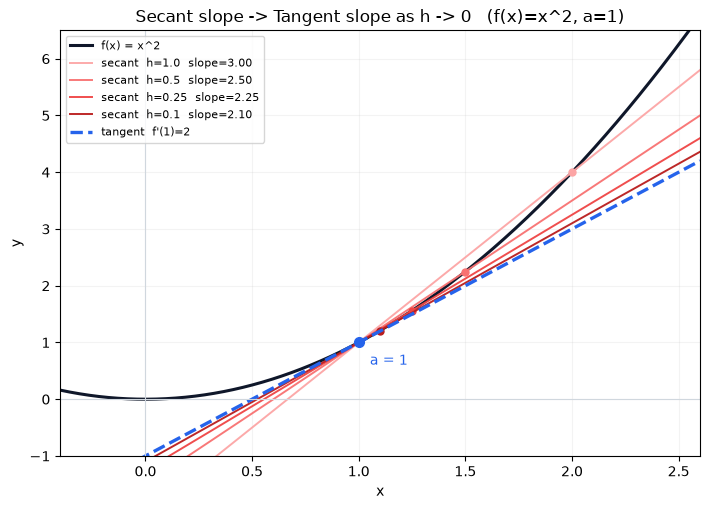

In [3]:
fn = lambda t: t**2          # f(x) = x^2
a0 = 1.0
slope = 2 * a0               # f'(1) = 2
xs = np.linspace(-0.4, 2.6, 400)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(xs, fn(xs), color="#0f172a", lw=2.2, label="f(x) = x^2")

cmap = ["#fca5a5", "#f87171", "#ef4444", "#b91c1c"]
for hv, col in zip([1.0, 0.5, 0.25, 0.1], cmap):
    m = (fn(a0 + hv) - fn(a0)) / hv          # secant slope
    line = fn(a0) + m * (xs - a0)
    ax.plot(xs, line, color=col, lw=1.4, alpha=0.95,
            label=f"secant  h={hv}  slope={m:.2f}")
    ax.plot([a0 + hv], [fn(a0 + hv)], "o", color=col, ms=5)

tangent = fn(a0) + slope * (xs - a0)
ax.plot(xs, tangent, color="#2563eb", lw=2.4, ls="--",
        label=f"tangent  f'(1)={slope:.0f}")
ax.plot([a0], [fn(a0)], "o", color="#2563eb", ms=7, zorder=5)
ax.annotate("a = 1", (a0, fn(a0)), textcoords="offset points", xytext=(8, -16), color="#2563eb")

ax.set_title("Secant slope -> Tangent slope as h -> 0   (f(x)=x^2, a=1)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_xlim(-0.4, 2.6); ax.set_ylim(-1.0, 6.5)
ax.axhline(0, color="#d0d7de", lw=.8); ax.axvline(0, color="#d0d7de", lw=.8)
ax.grid(alpha=.15); ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

## 3. 미분 = 자코비안 행렬의 추출, 그리고 두 법칙이 갈리는 이유
격식을 갖추면 미분은 **자코비안 행렬을 추출**하는 행위입니다.
곱의 선형화(곱미분)와 합성의 선형화(연쇄법칙)가 서로 다름을 SymPy로 확인합니다.
$$(g\circ f)'(x)=g'(f(x))\,f'(x),\qquad (fg)'(x)=f'(x)g(x)+f(x)g'(x)$$

In [4]:
fx, gx = sp.Function("f")(x), sp.Function("g")(x)

# chain rule:  (g ∘ f)' = g'(f(x)) · f'(x)
chain_lhs = sp.diff(sp.Function("g")(sp.Function("f")(x)), x)
print("chain rule   (g∘f)' =", chain_lhs)

# product rule: (f·g)' = f'·g + f·g'
prod_lhs = sp.diff(fx * gx, x)
print("product rule (f·g)' =", prod_lhs)

# concrete check: f = x^2+1, g = sin
f1, g1 = x**2 + 1, sp.sin(x)
print()
print("f = x²+1 , g = sin")
print("  (g∘f)'  =", sp.simplify(sp.diff(g1.subs(x, f1), x)),
      "  vs  g'(f)·f' =", sp.simplify(sp.cos(f1) * sp.diff(f1, x)))
print("  (f·g)'  =", sp.simplify(sp.diff(f1 * g1, x)),
      "  vs  f'g+fg' =", sp.simplify(sp.diff(f1, x) * g1 + f1 * sp.diff(g1, x)))

# the Jacobian: a 2->2 map linearised at a point is exactly a 2x2 matrix
u, v = sp.symbols("u v", real=True)
F = sp.Matrix([u**2 - v**2, 2 * u * v])
J = F.jacobian([u, v])
print("\nF(u,v) = (u²-v², 2uv)   Jacobian =", J.tolist(),
      "   at (1,1) =", J.subs({u: 1, v: 1}).tolist())

chain rule   (g∘f)' = Derivative(f(x), x)*Derivative(g(f(x)), f(x))
product rule (f·g)' = f(x)*Derivative(g(x), x) + g(x)*Derivative(f(x), x)

f = x²+1 , g = sin
  (g∘f)'  = 2*x*cos(x**2 + 1)   vs  g'(f)·f' = 2*x*cos(x**2 + 1)
  (f·g)'  = 2*x*sin(x) + (x**2 + 1)*cos(x)   vs  f'g+fg' = 2*x*sin(x) + (x**2 + 1)*cos(x)

F(u,v) = (u²-v², 2uv)   Jacobian = [[2*u, -2*v], [2*v, 2*u]]    at (1,1) = [[2, -2], [2, 2]]


## 4. 기본 함수들의 미분 — 다항·지수·로그·삼각
보드게임 규칙처럼 외워 두는 기본형. SymPy 로 모두 검산합니다.
$$(\sin x)'=\cos x,\quad (\cos x)'=-\sin x,\quad (\tan x)'=\sec^2 x,\quad (e^x)'=e^x,\quad (\ln x)'=\tfrac1x$$

  d/dx [2*x**2 + 3*x + 1] = 4*x + 3
  d/dx [      exp(x)] = exp(x)
  d/dx [      log(x)] = 1/x
  d/dx [      sin(x)] = cos(x)
  d/dx [      cos(x)] = -sin(x)
  d/dx [      tan(x)] = cos(x)**(-2)

check (2x²+3x+1)' == 4x+3 : True
check (tan x)'   == sec²x : True


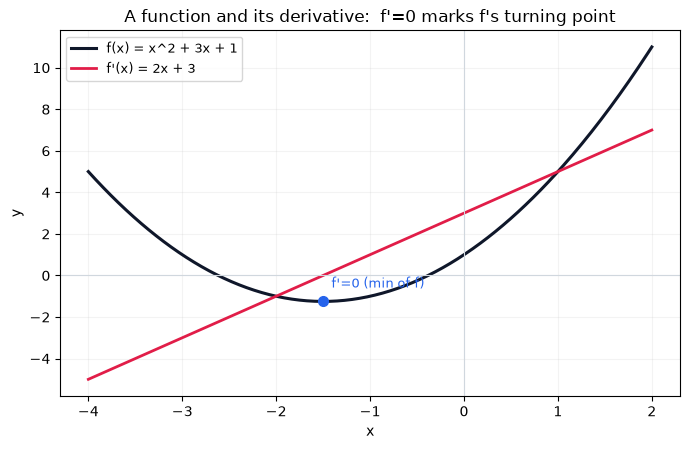

In [5]:
basics = [
    2*x**2 + 3*x + 1,   # -> 4x + 3
    sp.exp(x),          # -> e^x
    sp.log(x),          # -> 1/x
    sp.sin(x),          # -> cos x
    sp.cos(x),          # -> -sin x
    sp.tan(x),          # -> sec^2 x = 1 + tan^2 x
]
for fexpr in basics:
    print(f"  d/dx [{str(fexpr):>12}] = {sp.simplify(sp.diff(fexpr, x))}")
print("\ncheck (2x²+3x+1)' == 4x+3 :", sp.diff(2*x**2 + 3*x + 1, x) == 4*x + 3)
print("check (tan x)'   == sec²x :",
      sp.simplify(sp.diff(sp.tan(x), x) - sp.sec(x)**2) == 0)

# f and f' for f = x^2 + 3x + 1, plotted together
fexpr = x**2 + 3*x + 1
fp = sp.diff(fexpr, x)
F = sp.lambdify(x, fexpr, "numpy")
Fp = sp.lambdify(x, fp, "numpy")
xs = np.linspace(-4, 2, 300)
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(xs, F(xs), color="#0f172a", lw=2.2, label="f(x) = x^2 + 3x + 1")
ax.plot(xs, Fp(xs) * np.ones_like(xs), color="#e11d48", lw=2.0,
        label="f'(x) = 2x + 3")
ax.axhline(0, color="#d0d7de", lw=.8); ax.axvline(0, color="#d0d7de", lw=.8)
xr = float(sp.solve(fp, x)[0])            # f' = 0 -> minimum of f
ax.plot([xr], [F(xr)], "o", color="#2563eb", ms=7)
ax.annotate("f'=0 (min of f)", (xr, F(xr)), textcoords="offset points",
            xytext=(6, 10), color="#2563eb", fontsize=9)
ax.set_title("A function and its derivative:  f'=0 marks f's turning point")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.grid(alpha=.15); ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 6. 연쇄법칙과 곱미분을 섞기
강의의 확인 예시를 그대로 검산합니다.
$\sin(x^2)'=\cos(x^2)\cdot 2x$, $\;\ln(x^3)'=\tfrac{3}{x}$, 그리고 두 몬스터의 합성 $\sin(\tan(x^2))$ 까지.

In [6]:
exprs = {
    "sin(x²)":          sp.sin(x**2),
    "ln(x³)":           sp.log(x**3),
    "tan(x)":           sp.tan(x),
    "(x+1)/(x+2)":      (x + 1) / (x + 2),
    "e^{-x²}":          sp.exp(-x**2),
    "sin(tan x)":       sp.sin(sp.tan(x)),
    "sin(tan(x²))":     sp.sin(sp.tan(x**2)),
}
for name, e in exprs.items():
    print(f"  d/dx [{name:>14}] = {sp.simplify(sp.diff(e, x))}")

print("\nspot checks:")
print("  sin(x²)'  == cos(x²)·2x :",
      sp.simplify(sp.diff(sp.sin(x**2), x) - sp.cos(x**2) * 2 * x) == 0)
print("  ln(x³)'   == 3/x        :",
      sp.simplify(sp.diff(sp.log(x**3), x) - 3 / x) == 0)

  d/dx [       sin(x²)] = 2*x*cos(x**2)
  d/dx [        ln(x³)] = 3/x
  d/dx [        tan(x)] = cos(x)**(-2)
  d/dx [   (x+1)/(x+2)] = (x + 2)**(-2)
  d/dx [       e^{-x²}] = -2*x*exp(-x**2)
  d/dx [    sin(tan x)] = cos(tan(x))/cos(x)**2
  d/dx [  sin(tan(x²))] = 2*x*cos(tan(x**2))/cos(x**2)**2

spot checks:
  sin(x²)'  == cos(x²)·2x : True
  ln(x³)'   == 3/x        : True


## 7. 적분 — 미분의 역연산
"$f'$ 이 주어졌을 때 $f$ 를 구하라." 미분을 거꾸로 따라갑니다(상수 $C$ 주의).
$$\int\frac1x\,dx=\ln x+C,\qquad \int 2x\cos(x^2)\,dx=\sin(x^2)+C,\qquad \int\sin x\,dx=-\cos x+C$$

In [7]:
pairs = [
    (1 / x,                 "1/x"),
    (2 * x * sp.cos(x**2),  "2x·cos(x²)"),
    (sp.sin(x),             "sin x"),
    (sp.exp(x),             "e^x"),
]
for integrand, name in pairs:
    F = sp.integrate(integrand, x)
    print(f"  ∫ {name:>12} dx = {F} (+ C)   d/dx back = {sp.simplify(sp.diff(F, x))}")

# round-trip: differentiate sin(x²) then integrate -> recover sin(x²)
g = sp.sin(x**2)
print("\nround trip:  d/dx sin(x²) =", sp.diff(g, x),
      "   ∫ that dx =", sp.integrate(sp.diff(g, x), x), "(+ C)")

  ∫          1/x dx = log(x) (+ C)   d/dx back = 1/x
  ∫   2x·cos(x²) dx = sin(x**2) (+ C)   d/dx back = 2*x*cos(x**2)
  ∫        sin x dx = -cos(x) (+ C)   d/dx back = sin(x)
  ∫          e^x dx = exp(x) (+ C)   d/dx back = exp(x)

round trip:  d/dx sin(x²) = 2*x*cos(x**2)    ∫ that dx = sin(x**2) (+ C)


## 8. 적분의 두 성질 — 치환적분·부분적분, 그리고 호환성 문제
곱미분 ↔ **부분적분**, 연쇄법칙 ↔ **치환적분** 으로 짝지어지지만 정확히 호환되지는 않습니다.
부분적분 $\int u\,dv = uv-\int v\,du$ 를 $\int x e^x dx$ 로, 치환적분을 $\int 2x\cos(x^2)dx$ 로 확인합니다.

In [8]:
# integration by parts:  ∫ x e^x dx = x e^x - e^x
u_, dv = x, sp.exp(x)
v_ = sp.integrate(dv, x)
by_parts = u_ * v_ - sp.integrate(v_ * sp.diff(u_, x), x)
print("by parts  ∫ x e^x dx =", sp.simplify(by_parts),
      "   sympy =", sp.integrate(x * sp.exp(x), x))

# change of variable:  ∫ 2x cos(x²) dx, let t = x²
t = sp.symbols("t", real=True)
sub = sp.integrate(sp.cos(t), t).subs(t, x**2)     # ∫ cos t dt = sin t -> sin(x²)
print("substitution  ∫ 2x cos(x²) dx =", sub,
      "   sympy =", sp.integrate(2 * x * sp.cos(x**2), x))

# the "not exactly compatible" reminder: some elementary integrands have no elementary antiderivative
hard = sp.integrate(sp.exp(-x**2), x)
print("\n∫ e^{-x²} dx =", hard, " (no elementary form -> shows up as erf)")

by parts  ∫ x e^x dx = (x - 1)*exp(x)    sympy = (x - 1)*exp(x)
substitution  ∫ 2x cos(x²) dx = sin(x**2)    sympy = sin(x**2)

∫ e^{-x²} dx = sqrt(pi)*erf(x)/2  (no elementary form -> shows up as erf)
